
# **Academic Integrity and Learning Statement**

By submitting my work, I confirm that:

- The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
- I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


# **Unit E. EDA: Time-series data**
#### **Introduction**

Another data type that requires specific methods and skills for analysis is time-series data. Although the Open Food database is not a time-series database, it contains several columns with dates and times, allowing for a simple investigation. The goal of this unit is to work with the created_at column that stores the date and time at which products were added to the Open Food database and create two visualizations of the data to understand it better. 

#### **Table of content**

1) Plotting the total number of items created each month at each hour. 
2) Plotting the evolution of the total number of items over time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("data_clean.csv")
df["created_at"] = pd.to_datetime(df["created_at"])

/home/ruop/miniconda3/envs/adsml/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3441: DtypeWarning: Columns (1,43,45) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


### **1) Plotting the total number of items created each mont at each hour**
The goal is to investigate the total number of items created each month at each hour. 

For this task, I will use the created_at column to draw a heatmap with the hours (0 to 23) on the x-axis and the months (1 to 12) on the y-axis.

I will start by grouping the data by month / hour and calculate the resulting number of items. This creates a data frame with a multi-index (month, hour) and the number of products created as value. I will then unstack this data frame so that we can plot months vs hour.

In [2]:
counts = df.groupby([df["created_at"].dt.month, df["created_at"].dt.hour])["product_name_en"].size()

# unstack is necessary for the heatmap, we want month vs hour
counts = counts.unstack()

counts.columns.name = "Hours"
counts.index.name = "Months"

# fill 0 for missing values
counts = counts.fillna(0)
counts

Hours,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Months,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,75.0,123.0,...,40.0,29.0,5.0,21.0,37.0,6.0,13.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,152.0,97.0,...,30.0,16.0,3.0,5.0,0.0,36.0,5.0,23.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,24.0,244.0,136.0,...,383.0,370.0,75.0,8.0,5.0,12.0,43.0,3.0,0.0,1.0
4,0.0,0.0,0.0,0.0,5.0,19.0,229.0,90.0,150.0,123.0,...,69.0,9.0,9.0,12.0,2.0,83.0,5.0,17.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,3.0,79.0,42.0,19.0,...,23.0,7.0,7.0,133.0,48.0,5.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,20.0,35.0,28.0,48.0,...,103.0,17.0,113.0,146.0,41.0,0.0,3.0,4.0,186.0,41.0
7,22.0,2.0,0.0,0.0,0.0,0.0,225.0,37.0,29.0,40.0,...,46.0,34.0,133.0,93.0,72.0,54.0,219.0,31.0,21.0,185.0
8,11.0,12.0,7.0,2.0,0.0,8.0,31.0,118.0,63.0,315.0,...,95.0,79.0,180.0,97.0,69.0,175.0,67.0,38.0,25.0,3.0
9,0.0,0.0,0.0,0.0,0.0,0.0,49.0,49.0,40.0,276.0,...,210.0,65.0,180.0,596.0,1195.0,96.0,0.0,39.0,0.0,0.0


Let's now plot the data using a heatmap (seaborn).

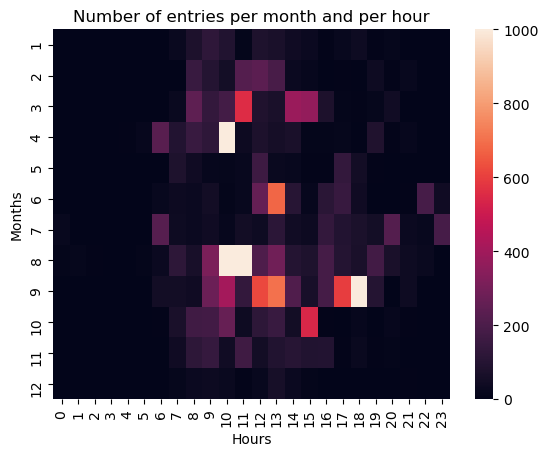

In [3]:
import seaborn as sns
sns.heatmap(counts, vmin=0, vmax=1000)
plt.title("Number of entries per month and per hour")
plt.show()


We observe that more entries were created around noon (or at least during working hours). Almost no entries were created during the night (black). 

### **2) Investigating the evolution of the total number of items over time**

For this task, I will draw a bar plot with the date (e.g., in yyyy-mm format) on the x-axis and the total number of items created during each month on the y-axis. Each bar in the plot will stack the number of items created by each country each month. 

I will start by creating a data frame with the number of items created for each country every month.

In [4]:
df_country_months = df.groupby("country").resample("M", on="created_at").size()

Let's now make sure the data frame is in a format that we can plot, and let's only keep the date in the index (not the time and the timezone).

In [5]:
# Make your data frame in a format that's easier to plot
df_country_months = df_country_months.unstack().transpose()

# Keep only the date in the index, not the time and timezone
df_country_months.index = df_country_months.index.date

Let's now plot the data!

/home/ruop/miniconda3/envs/adsml/lib/python3.9/site-packages/pandas/plotting/_core.py:1746: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


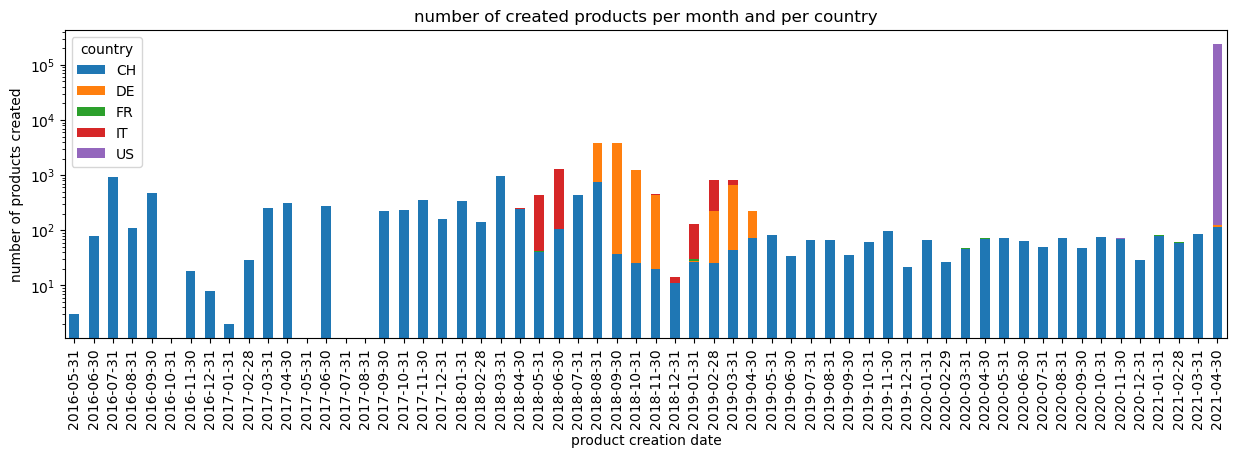

In [6]:
df_country_months.plot(kind="bar", stacked=True, figsize=(15,4))
plt.yscale("log")
plt.xlabel("product creation date")
plt.ylabel("number of products created")
plt.title("number of created products per month and per country")
plt.show()

Interestingly we see that all of the entries for the US were added at more or less the same time, while the database has been updated much more regularly for swiss products. For Italian and german products, most were created in 2018-2019. 